# 03 · Trends and normals

What should "crime is up in Albany Park" mean? This notebook rebuilds, in pandas, the numbers notebook
`04_gold_area_trend_metrics` computes in Spark for every area and metric, and shows why each one is
defined the way it is:

1. **The partial-month trap**, and the projection the app uses instead.
2. **Trailing windows**: the last 30 days against the 30 before.
3. **Normal for this time of year**: the baseline the map, the area panel and the forecast all share.
4. **Crime per resident**: where an area usually sits, whatever its trend.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent   # run from the repo root or tutorials/
sys.path[:0] = [str(ROOT), str(ROOT / "tutorials")]

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import _data
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e1e0d9", "axes.prop_cycle": plt.cycler(color=["#2a78d6", "#eb6834", "#1baf7a", "#898781"])})
pd.set_option("display.width", 160, "display.max_columns", 30)
print("data from:", _data.source())

import calendar
from datetime import timedelta

from src import area_data
from src.community_areas import AREA_NAMES, POPULATION
from src.constants import level_band

daily = _data.crime_daily_by_area()
city = daily.groupby("day")["n"].sum().reset_index()
as_of = _data.last_full_day(city)
daily = daily[daily["day"] <= as_of]
print(f"{len(daily):,} area-days through {as_of} (the last full day)")

# a dense day x area matrix makes every window a slice
wide = daily.pivot_table(index="day", columns="community_area", values="n", aggfunc="sum").fillna(0)
wide.index = pd.to_datetime(wide.index)
wide = wide.reindex(pd.date_range(wide.index.min(), as_of), fill_value=0)
span = lambda first, last: wide.loc[pd.Timestamp(first):pd.Timestamp(last)].sum()

data from: local exports


671,033 area-days through 2026-09-11 (the last full day)


## 1. The partial-month trap

The first version of the app compared this calendar month with last month. Early in a month that's
a few days against a full month, so every area looked like it was improving. Here's Albany Park
(area 14), month by month, as of the data's last full day:

In [2]:
AREA = 14
monthly = wide[AREA].resample("MS").sum()
history = [{"period": p.date().isoformat(), "count": int(n)} for p, n in monthly.tail(7).items()]
area_data.annotate_partial_month(history, as_of)       # the app's projection, from src/area_data.py
pd.DataFrame(history).set_index("period")

,count,partial,days_observed,days_in_month,projected_count
period,,,,,
2026-03-01,174,NaN,NaN,NaN,NaN
2026-04-01,165,NaN,NaN,NaN,NaN
2026-05-01,191,NaN,NaN,NaN,NaN
2026-06-01,197,NaN,NaN,NaN,NaN
2026-07-01,174,NaN,NaN,NaN,NaN
2026-08-01,197,NaN,NaN,NaN,NaN
2026-09-01,71,True,11.0,30.0,194.0


The last month is marked `partial`, and `projected_count` is a straight-line projection to a full month
(count × days in month / days observed): the app says "on pace for about N" instead of showing a false
drop. Notebook `04` cuts the monthly table at the same as-of date, so count and divisor cover the same
days. For "better or worse right now", though, the app uses complete windows.

## 2. Trailing windows

The last 30 days against the 30 days before, both ending on the as-of date, so both sides are always
complete. `area_trend_rolling` holds this for 30, 60 and 90 days.

In [3]:
W = 30
cur = span(as_of - timedelta(days=W - 1), as_of)
prior = span(as_of - timedelta(days=2 * W - 1), as_of - timedelta(days=W))
windows = pd.DataFrame({"area": [AREA_NAMES[a] for a in cur.index], "last_30": cur.astype(int), "prior_30": prior.astype(int)})
windows["pct_vs_prior"] = (windows["last_30"] / windows["prior_30"] - 1) * 100
windows.sort_values("pct_vs_prior", ascending=False).head(8).round(1)

,area,last_30,prior_30,pct_vs_prior
community_area,,,,
12,Forest Glen,36,23,56.5
50,Pullman,122,81,50.6
74,Mount Greenwood,57,41,39.0
7,Lincoln Park,330,276,19.6
58,Brighton Park,167,140,19.3
65,West Lawn,147,125,17.6
18,Montclare,34,29,17.2
16,Irving Park,176,151,16.6


Small areas swing wildly in percentage terms (2 → 4 is +100%). The app shows absolute changes below a
prior count of 10, and the agent's cross-area ranking skips areas under a minimum baseline.

The bigger problem is that "vs. the prior window" depends on what the prior window happened to hold.
An area coming off an unusually quiet stretch reads as a spike; late summer always beats early spring.

## 3. Normal for this time of year

`area_trend_normals` compares the window with what the area's own past year predicts for this time of
year:

- **normal** = the area's daily rate over the 364 days before the window × 30 × a seasonal factor
- **seasonal factor** = the citywide count in the same 30 days 1, 2 and 3 years back (shifted by whole
  weeks, so weekdays line up), each divided by the citywide pace of the year before it. The median of the
  three, so one odd year doesn't decide it.

In [4]:
YEAR = 364
start = as_of - timedelta(days=W - 1)
trail = span(start - timedelta(days=YEAR), start - timedelta(days=1))
ratios = []
for k in (1, 2, 3):
    shift = timedelta(days=YEAR * k)
    ref = span(start - shift, as_of - shift).sum()
    ref_trail = span(start - shift - timedelta(days=YEAR), start - shift - timedelta(days=1)).sum()
    ratios.append(ref / (ref_trail * W / YEAR))
season = float(np.median(ratios))
normal = trail / YEAR * W * season
windows["normal"] = normal.round(1)
windows["pct_vs_normal"] = (windows["last_30"] / normal - 1) * 100
print(f"seasonal factor for these 30 days: {season:.3f} (from {', '.join(f'{r:.3f}' for r in ratios)})")
print(f"citywide: {int(cur.sum()):,} crimes vs. a normal of {normal.sum():,.0f} ({(cur.sum() / normal.sum() - 1) * 100:+.1f}%), "
      f"and {(cur.sum() / prior.sum() - 1) * 100:+.1f}% vs. the prior 30 days")

seasonal factor for these 30 days: 1.038 (from 1.003, 1.038, 1.066)
citywide: 19,786 crimes vs. a normal of 19,827 (-0.2%), and -2.2% vs. the prior 30 days


The two comparisons often disagree. Plotted against each other, each dot is an area: the ones far off
the diagonal are where "vs. the prior window" tells a different story from "vs. normal".

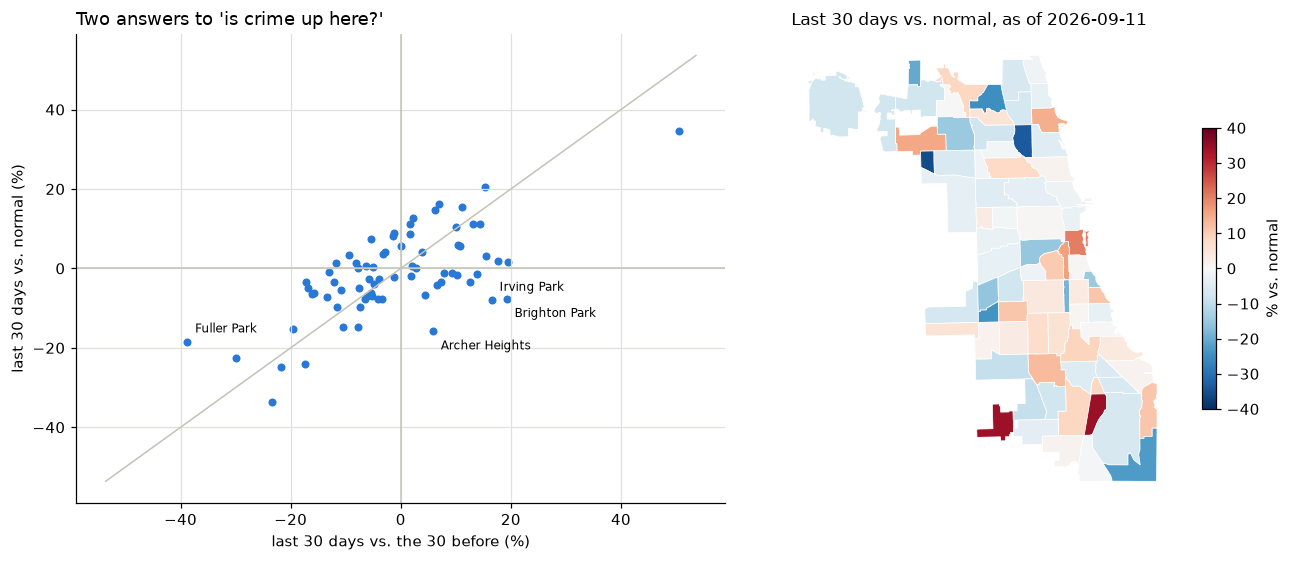

In [5]:
big = windows[windows["prior_30"] >= 50]
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), gridspec_kw={"width_ratios": [1.2, 1]})
ax = axes[0]
ax.scatter(big["pct_vs_prior"], big["pct_vs_normal"], s=18)
lim = max(big[["pct_vs_prior", "pct_vs_normal"]].abs().max()) + 3
ax.plot([-lim, lim], [-lim, lim], color="#c3c2b7", lw=1)
ax.axhline(0, color="#c3c2b7", lw=1); ax.axvline(0, color="#c3c2b7", lw=1)
off = (big["pct_vs_prior"] - big["pct_vs_normal"]).abs().nlargest(4).index
for i, a in enumerate(off):
    ax.annotate(AREA_NAMES[a], (big.at[a, "pct_vs_prior"], big.at[a, "pct_vs_normal"]), fontsize=8,
                xytext=(5, 6 if i % 2 else -12), textcoords="offset points")
ax.set_xlabel("last 30 days vs. the 30 before (%)"); ax.set_ylabel("last 30 days vs. normal (%)")
ax.set_title("Two answers to 'is crime up here?'", loc="left")
_data.choropleth(windows["pct_vs_normal"].clip(-40, 40).to_dict(), ax=axes[1], cmap="RdBu_r", vmin=-40, vmax=40,
                 title=f"Last 30 days vs. normal, as of {as_of}", label="% vs. normal")
plt.tight_layout(); plt.show()

The right-hand map is the app's default "Trend Map" layer. The same baseline at weekly grain is the
"normal" the next-week forecast calls up or down against (tutorial 05), so the map, the area panel and
the forecast all measure against one thing.

## 4. Where an area usually sits: crime per resident

Trends say whether an area is getting better or worse, not where it sits. An area running 10% below
its normal can still be far above one running 10% over its own. `area_profile` holds each area's count
per 1,000 residents over the last 12 months, its citywide percentile, and a plain-words band
(`src/constants.level_band`). The app's headline is violent crime.

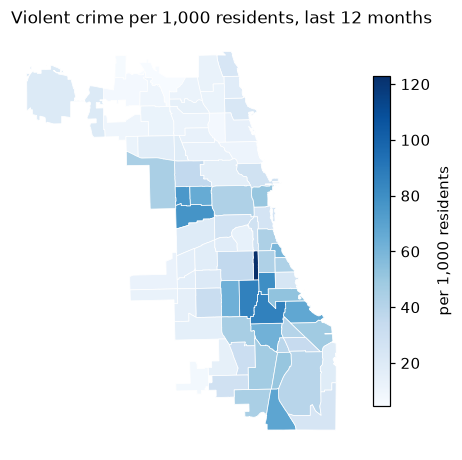

,area,violent_per_1k,percentile,level
community_area,,,,
37,Fuller Park,123.1,100,among the highest
69,Greater Grand Crossing,86.2,97,among the highest
68,Englewood,86.2,99,among the highest
41,Hyde Park,24.1,50,near the middle
1,Rogers Park,23.7,49,near the middle
9,Edison Park,5.9,1,among the lowest
12,Forest Glen,4.6,0,among the lowest


In [6]:
cats = _data.crime_monthly_by_category()
last12 = sorted(cats["period"].unique())[-13:-1]               # the last 12 complete months
violent = cats[(cats["metric"] == "crime_violent") & cats["period"].isin(last12)].groupby("community_area")["metric_count"].sum()
rate = violent / pd.Series(POPULATION) * 1000
pct = rate.rank(pct=True, method="min").sub(1 / len(rate)).mul(100 * len(rate) / (len(rate) - 1))
profile = pd.DataFrame({"area": [AREA_NAMES[a] for a in rate.index], "violent_per_1k": rate.round(1),
                        "percentile": pct.round().astype(int)})
profile["level"] = [level_band(p)["label"] for p in profile["percentile"]]
fig, ax = plt.subplots(figsize=(5, 6.5))
_data.choropleth(rate.to_dict(), ax=ax, cmap="Blues", title="Violent crime per 1,000 residents, last 12 months",
                 label="per 1,000 residents")
plt.show()
profile.sort_values("violent_per_1k", ascending=False).iloc[[0, 1, 2, 38, 39, -2, -1]]

One caveat the app spells out: the Loop and Near North Side draw far more workers and visitors than
residents, so their per-resident rates run high, especially for theft.

## What notebook 04 adds

The Spark version does all of this for every metric (crime by category, 311 by type), for 30, 60 and
90-day windows, with **zero-filled grids** (an area-month with no incidents is a 0, not a missing row),
and declares primary keys so `area_trend_metrics` and `area_trend_rolling` can be synced into Lakebase.

Next: [04 · Leading indicators](04_leading_indicators.ipynb): does 311 activity come before crime?